<a href="https://colab.research.google.com/github/Dharshini13002/Deep-learning-codes-of-FER/blob/main/FER2013LSTM_MODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
# Kaggle API setup
os.environ["KAGGLE_USERNAME"] = "dharshini1333333"  # Replace with your Kaggle username
os.environ["KAGGLE_KEY"] = "cecd150b72b85d04cc229a681a646b88"  # Replace with your Kaggle API key

In [3]:
from kaggle.api.kaggle_api_extended import KaggleApi

In [4]:
# Enable CuDNN benchmarking for performance
cudnn.benchmark = True
plt.ion()  # Enable interactive mode for matplotlib

In [5]:
# Use the existing Fer2013 dataset if present
data_dir = '/content/fer2013.csv'
if os.path.exists(data_dir):
    print("FER2013 dataset already exists at:", data_dir)
else:
    print("FER2013 dataset not found at:", data_dir)
    print("Downloading the dataset using Kaggle API...")
    api = KaggleApi()
    api.authenticate()
    api.dataset_download_files('deadskull7/fer2013', path='/content/', unzip=True)
    print("Dataset downloaded and unzipped successfully.")

FER2013 dataset not found at: /content/fer2013.csv
Dataset URL: https://www.kaggle.com/datasets/deadskull7/fer2013
Dataset downloaded and unzipped successfully.


In [6]:
# Data transformations for training and validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}


In [8]:
df = pd.read_csv('/content/fer2013.csv')
display(df.head())

,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


In [9]:
# Split the data into training, validation, and test sets
train_df = df[df['Usage'] == 'Training']
val_df = df[df['Usage'] == 'PublicTest']
test_df = df[df['Usage'] == 'PrivateTest']

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

Training samples: 28709
Validation samples: 3589
Test samples: 3589


In [10]:
# Define a custom dataset class
class Fer2013Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.labels = dataframe['emotion'].values
        self.pixels = dataframe['pixels'].apply(lambda x: np.array(x.split(), dtype='float32').reshape(48, 48)).values

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        label = self.labels[idx]
        image = self.pixels[idx]

        # Reshape for LSTM: treat each row of the 48x48 image as a timestep
        image = image.reshape(48, 48)  # Ensure shape is (timesteps=48, features=48)

        if self.transform:
            image = self.transform(image)

        return image, label

# Define transforms for LSTM (no RGB conversion, keep grayscale)
data_transforms = {
    'train': transforms.Compose([
        transforms.ToTensor(),  # Convert to tensor
        transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize grayscale
    ]),
    'val': transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ]),
    'test': transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ]),
}

In [11]:
# Create custom datasets
image_datasets = {
    'train': Fer2013Dataset(train_df, transform=data_transforms['train']),
    'val': Fer2013Dataset(val_df, transform=data_transforms['val']),
    'test': Fer2013Dataset(test_df, transform=data_transforms['test'])
}

In [12]:
# Create dataloaders
dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=64, shuffle=True, num_workers=2 if torch.cuda.is_available() else 0)
    for x in ['train', 'val', 'test']
}


In [13]:
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}

In [14]:
# Define the class names (emotions)
class_names = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [15]:
# Define the LSTM model
class LSTMFER(nn.Module):
    def __init__(self, input_size=48, hidden_size=128, num_layers=2, num_classes=7):
        super(LSTMFER, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc1 = nn.Linear(hidden_size, 64)
        self.fc2 = nn.Linear(64, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        # x shape: (batch_size, 1, 48, 48) -> reshape to (batch_size, 48, 48) for LSTM
        x = x.squeeze(1)  # Remove channel dimension
        # Initialize hidden state
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)

        # LSTM forward pass
        out, _ = self.lstm(x, (h0, c0))  # out: (batch_size, 48, hidden_size)
        out = out[:, -1, :]  # Take the output from the last timestep
        out = self.relu(self.fc1(out))
        out = self.dropout(out)
        out = self.fc2(out)
        return out


In [16]:
# Initialize model, loss function, and optimizer
model = LSTMFER().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [17]:
# Training loop
num_epochs = 20
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []


In [18]:
for epoch in range(num_epochs):
    # Training phase
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloaders['train']:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(dataloaders['train'])
    train_acc = 100 * correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)


In [19]:
    # Validation phase
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloaders['val']:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(dataloaders['val'])
    val_acc = 100 * correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

Epoch [20/20] Train Loss: 1.6751, Train Acc: 32.96%, Val Loss: 1.6805, Val Acc: 33.44%


In [20]:
# Test the model
model.eval()
test_correct = 0
test_total = 0
with torch.no_grad():
    for images, labels in dataloaders['test']:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_acc = 100 * test_correct / test_total
print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 33.88%


In [21]:
# Save the model
torch.save(model.state_dict(), 'fer2013_lstm_model.pth')

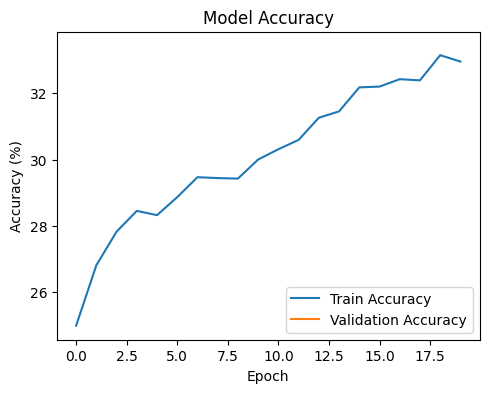

In [22]:
# Plot training and validation metrics
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

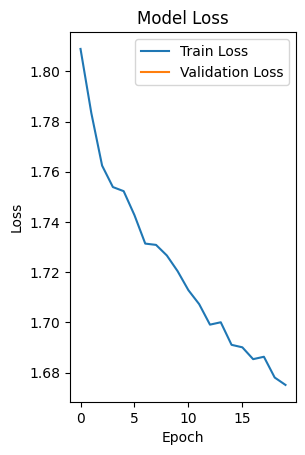

In [23]:
plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

In [24]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>